<h1>Project 3 - PHDENGUE ANALYSIS</h1>
<hr>
<h2>Analyst: Margarette Ann Felonia</h2>

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
from scipy.stats import f_oneway
warnings.filterwarnings('ignore')

<h2>Converting Dataset(s) into Dataframe</h2>
<hr>

In [2]:
dengue = pd.read_csv('datasets\\dengue.csv')

In [3]:
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [4]:
dengue.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,1020.0,2018.000000,1.414907,2016.0,2017.00,2018.0,2019.00,2020.0
Dengue_Cases,1020.0,1124.926471,1662.608878,10.0,247.75,582.5,1284.25,21658.0
Dengue_Deaths,1020.0,16.513725,96.358215,0.0,1.00,3.0,7.00,1651.0


<h1>Checking the null values</h1>
<hr>

In [5]:
dengue.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

In [6]:
dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


<h1>Changing the Data type</h1>
<hr>

In [7]:
dengue['Month']= dengue['Month'].astype('category')
dengue['Region']= dengue['Region'].astype('category')

In [8]:
dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Month          1020 non-null   category
 1   Year           1020 non-null   int64   
 2   Region         1020 non-null   category
 3   Dengue_Cases   1020 non-null   int64   
 4   Dengue_Deaths  1020 non-null   int64   
dtypes: category(2), int64(3)
memory usage: 27.1 KB


In [9]:
Regional_Death = dengue.groupby(["Region"])[['Dengue_Deaths', 'Dengue_Cases']].sum().reset_index()

In [10]:
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases
0,BARMM,332,11537
1,CAR,1008,30582
2,NCR,4008,115966
3,Region I,157,59066
4,Region II,193,45141
5,Region III,482,131064
6,Region IV-A,652,163029
7,Region IV-B,130,30849
8,Region IX,532,47781
9,Region V,185,22167


In [11]:
Regional_Death["Mortality_Rate"] = np.round((Regional_Death["Dengue_Deaths"] / Regional_Death["Dengue_Cases"]) * 100,2)

In [12]:
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases,Mortality_Rate
0,BARMM,332,11537,2.88
1,CAR,1008,30582,3.30
2,NCR,4008,115966,3.46
3,Region I,157,59066,0.27
4,Region II,193,45141,0.43
5,Region III,482,131064,0.37
6,Region IV-A,652,163029,0.40
7,Region IV-B,130,30849,0.42
8,Region IX,532,47781,1.11
9,Region V,185,22167,0.83


In [13]:
dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Month          1020 non-null   category
 1   Year           1020 non-null   int64   
 2   Region         1020 non-null   category
 3   Dengue_Cases   1020 non-null   int64   
 4   Dengue_Deaths  1020 non-null   int64   
dtypes: category(2), int64(3)
memory usage: 27.1 KB


<h1>Explanatory Data Analysis(EDA)</h1>
<hr>

<h2>Which regions recorded the highest average dengue mortality rate?</h2>

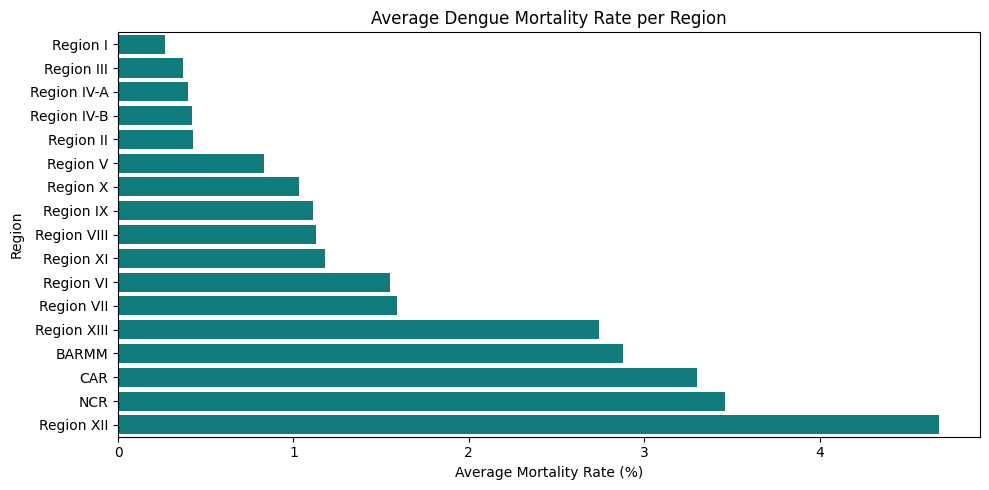

In [14]:
region_mortality = Regional_Death.groupby("Region")["Mortality_Rate"].mean().sort_values(ascending=True)

plt.figure(figsize=(10,5))
sns.barplot(
    x=region_mortality.values,
    y=region_mortality.index,
    color="darkcyan",
    order=region_mortality.index
)
plt.title("Average Dengue Mortality Rate per Region")
plt.xlabel("Average Mortality Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

<h4><b>INSIGHT:</b>The bar chart displays the average dengue mortality rate across different regions. NCR and Region XIII shows the highest mortality rate compared to all other regions. Regions XII, CAR, and BARMM also record relatively high values. Meanwhile, Regions III, I, II, IV-B and IV-A have the lowest mortality rates in the dataset. The visualization clearly highlights the differences in mortality levels among regions.</h4>

<h2>How did dengue deaths change throughout the months from 2016 to 2020?</h2>

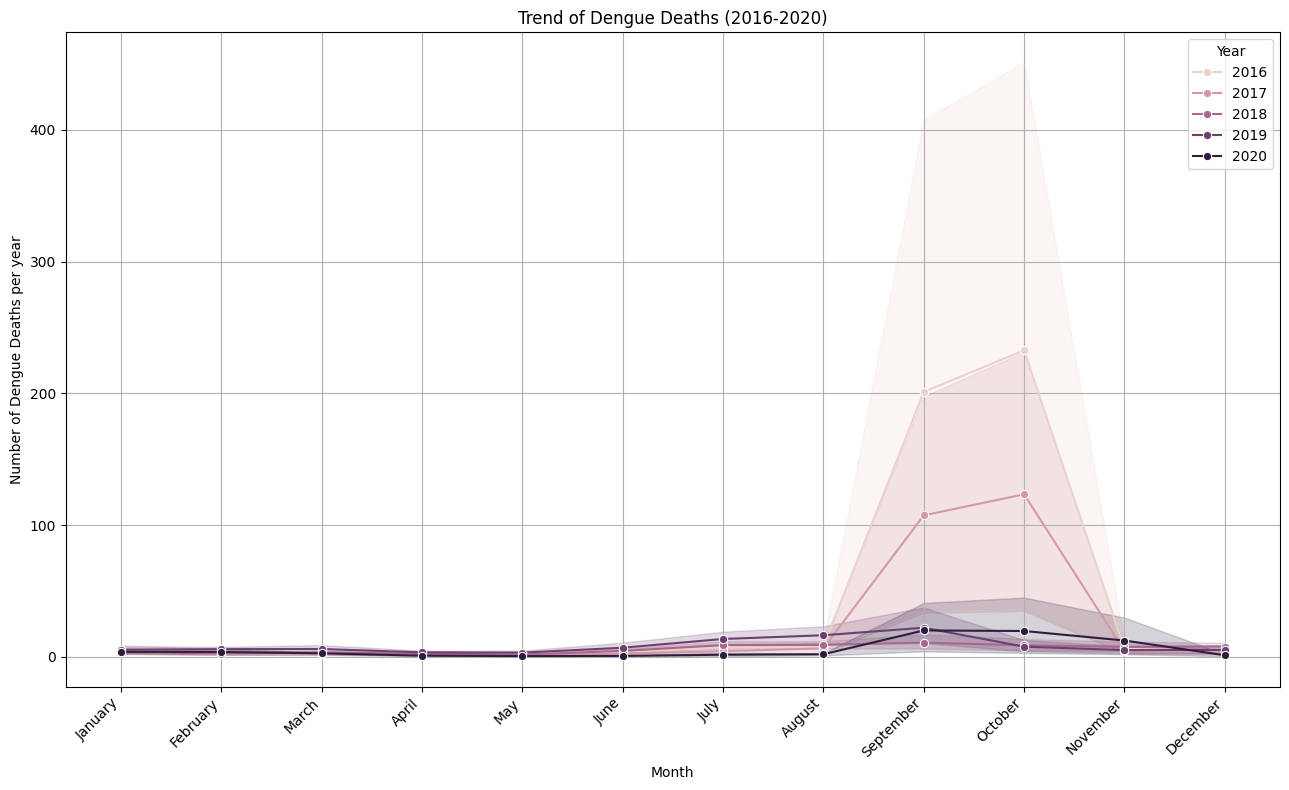

In [15]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
dengue['Month'] = pd.Categorical(dengue['Month'], categories=month_order, ordered=True)



# Create the line plot
sns.lineplot(data = dengue, x='Month', y='Dengue_Deaths', hue='Year', marker='o')
plt.gcf().set_size_inches(13,8)
plt.title('Trend of Dengue Deaths (2016-2020)')
plt.xlabel('Month')
plt.ylabel('Number of Dengue Deaths per year')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><b>INSIGHT:</b>The line chart shows the trend of dengue deaths from 2016 to 2020 across different months. Each year follows a similar pattern, with a noticeable rise in the middle months. The highest number of dengue deaths occurred in 2019. The cases begin to increase around June and peak between August and September. Afterward, the trend slowly declines toward the end of the year.</h4>

<h2>How do dengue cases vary across different months of the year?</h2>

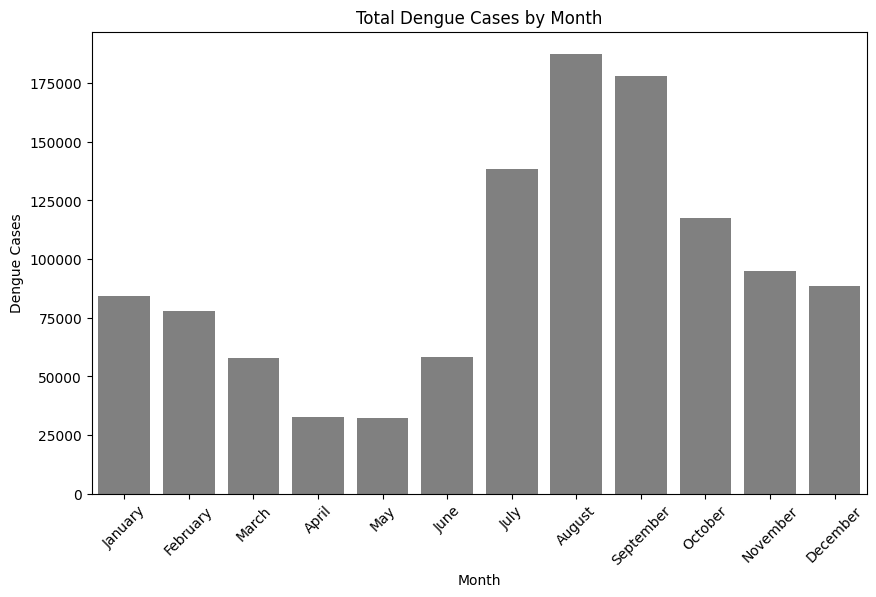

In [16]:
cases_per_month = dengue.groupby("Month")["Dengue_Cases"].sum()

plt.figure(figsize=(10,6))
sns.barplot(x=cases_per_month.index, y=cases_per_month.values, color="gray")
plt.title("Total Dengue Cases by Month")
plt.xlabel("Month")
plt.ylabel("Dengue Cases")
plt.xticks(rotation=45)
plt.show()


<h4><b>INSIGHT:</b>The bar chart presents the total number of dengue cases for each month. August records the highest total number of cases, followed by September. The lowest dengue cases are seen in April and May. The number of cases starts to rise gradually from June onward. After reaching its peak in August, the cases begin to drop as the year progresses.</h4>

<h2>How did dengue-related deaths vary across regions and years?</h2>

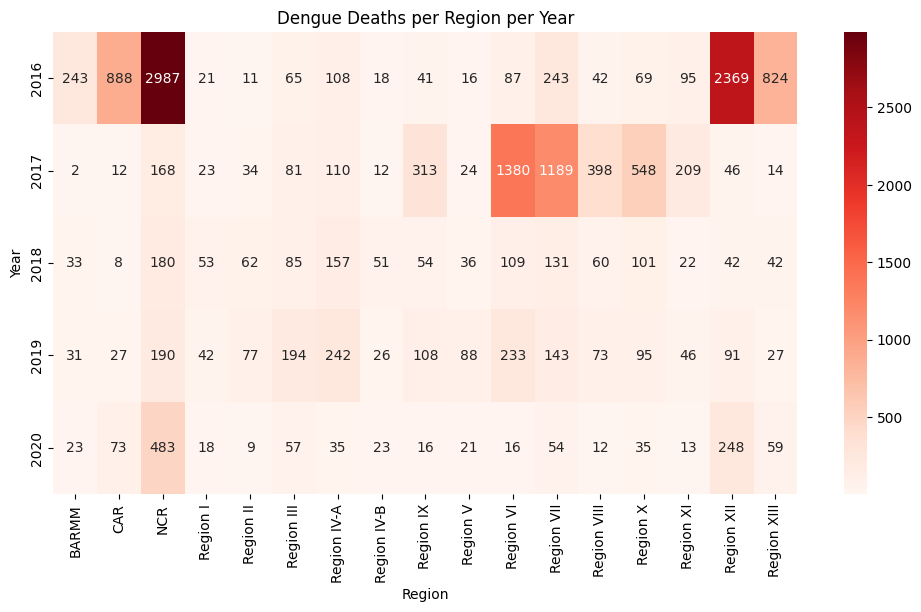

In [17]:
heatmap_data = dengue.groupby(["Year", "Region"])["Dengue_Deaths"].sum().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="Reds", annot=True, fmt=".0f")
plt.title("Dengue Deaths per Region per Year")
plt.xlabel("Region")
plt.ylabel("Year")
plt.show()


<h4><b>INSIGHT:</b>The heatmap illustrates dengue deaths across regions and years from 2016 to 2020. Darker shades represent regions with higher dengue deaths. NCR and Region XIII show the darkest shades, especially in the earlier years. Some regions, such as BARMM and CAR, show lighter shades, indicating lower deaths. The chart shows how the intensity of dengue deaths differs by both region and year.</h4>

<h2>Which region shows the highest variation in dengue cases over the years?</h2>

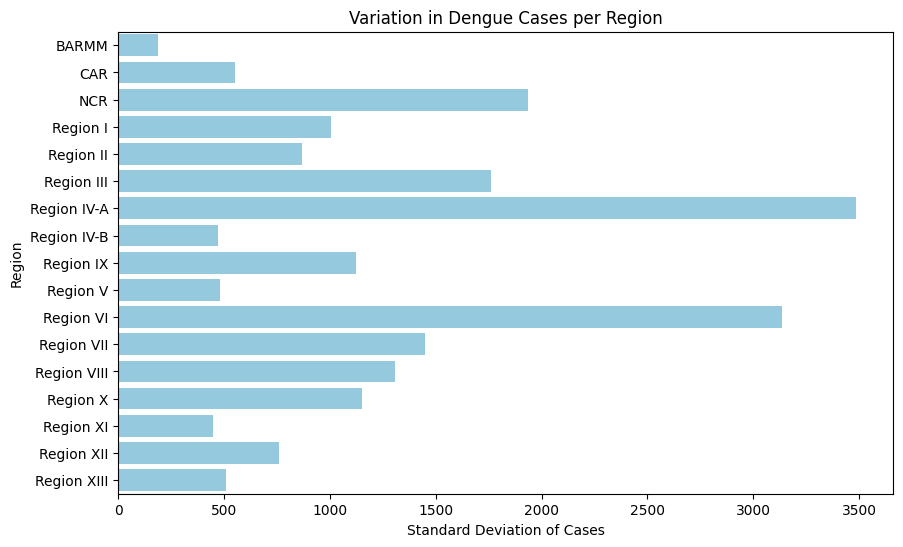

In [18]:
variation = dengue.groupby("Region")["Dengue_Cases"].std().sort_values()

plt.figure(figsize=(10,6))
sns.barplot(x=variation.values, y=variation.index, color="skyblue")
plt.title("Variation in Dengue Cases per Region")
plt.xlabel("Standard Deviation of Cases")
plt.ylabel("Region")
plt.show()


<h4><b>INSIGHT:</b>The graph shows the level of variation in dengue cases across different regions. BARMM displays the most stable number of dengue cases over time. Regions IV-A and Region VI show larger fluctuations compared to others. Several regions maintain moderate variation in their case numbers. This visualization emphasizes how the trend of dengue cases differs in consistency from one region to another.</h4>

<h2>During which months do dengue mortality rates usually increase across the years?</h2>

In [19]:
dengue['Mortality_Rate'] = np.round((dengue['Dengue_Deaths'] / dengue['Dengue_Cases']) * 100, 2)

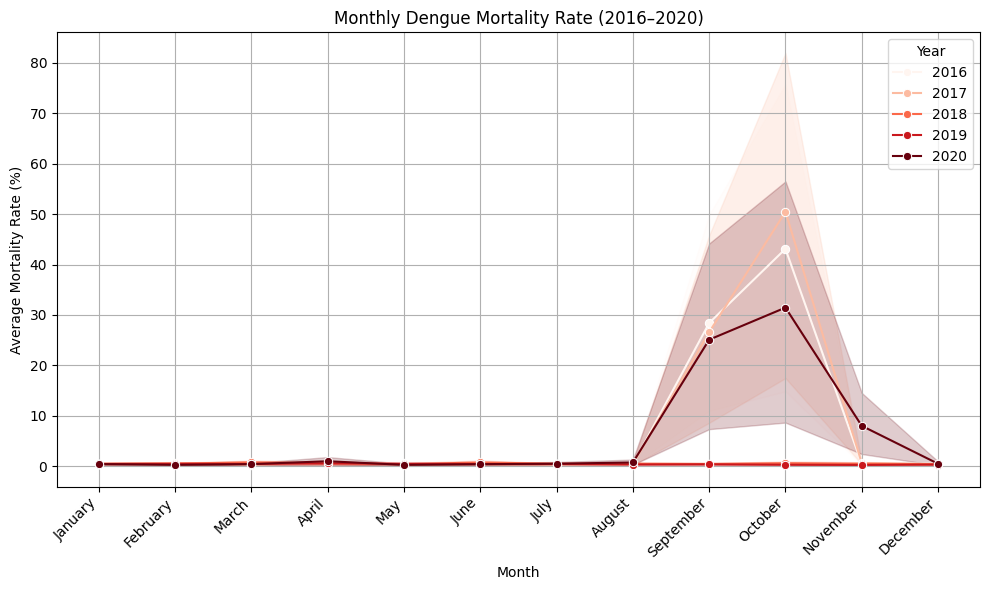

In [20]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

dengue['Month'] = pd.Categorical(dengue['Month'], categories=month_order, ordered=True)

# Filter for years 2016–2020
mortality_2016_2020 = dengue[dengue['Year'].between(2016, 2020)]

# Plot the line chart
plt.figure(figsize=(10,6))
sns.lineplot(
    data=mortality_2016_2020,
    x='Month',
    y='Mortality_Rate',
    hue='Year',
    marker='o',
    palette='Reds' 
)
plt.title('Monthly Dengue Mortality Rate (2016–2020)')
plt.xlabel('Month')
plt.ylabel('Average Mortality Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><b>INSIGHT:</b>The line graph tracks the monthly dengue mortality rate from 2016 to 2020, revealing notable trends over time. The years 2016 and 2017 experienced the highest mortality rates, particularly in the later months of the year. Before August, the mortality rate remained consistently low across all years. </h4>

<h2>How did dengue cases vary across different regions from 2016 to 2020?</h2>

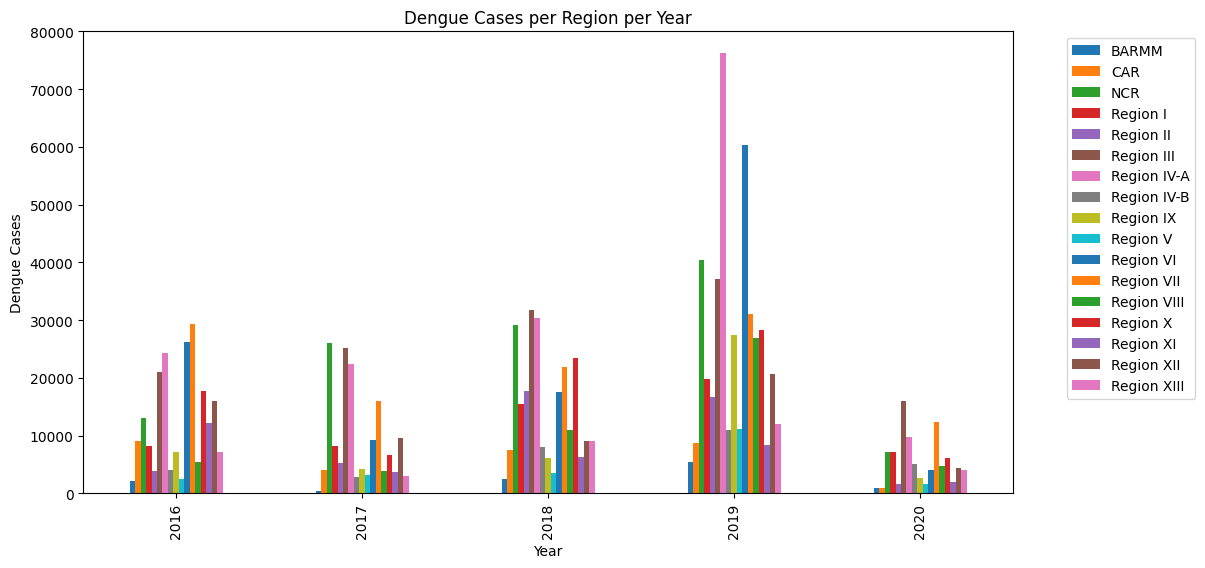

In [21]:
cases_per_region_year = dengue.groupby(["Year", "Region"])["Dengue_Cases"].sum().unstack()

cases_per_region_year.plot(kind="bar", figsize=(12,6))
plt.title("Dengue Cases per Region per Year")
plt.xlabel("Year")
plt.ylabel("Dengue Cases")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


<h4><b>INSIGHT:</b>The bar graph illustrates the yearly dengue cases across regions between 2016 and 2020. The year 2019 shows a significant surge in dengue cases, far higher than the other years. Regions XIII and BARMM stand out as having the most cases during this year. The trend highlights how dengue incidence fluctuated over time, peaking sharply in 2019 before dropping in 2020.</h4>

<h2>What is the distribution of dengue cases and mortality rates among regions?</h2>

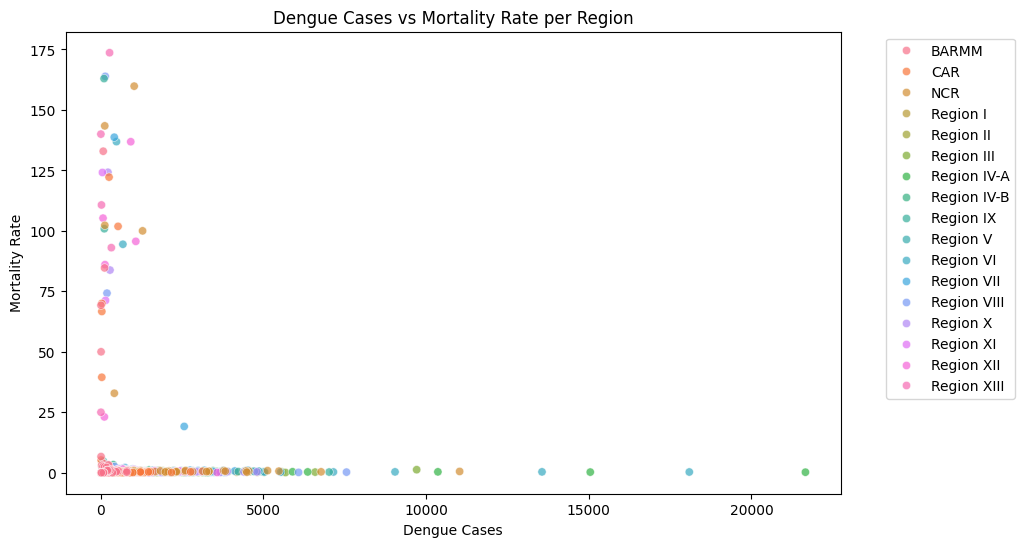

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=dengue, x="Dengue_Cases", y="Mortality_Rate", hue="Region", alpha=0.7)
plt.title("Dengue Cases vs Mortality Rate per Region")
plt.xlabel("Dengue Cases")
plt.ylabel("Mortality Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


<h4><b>INSIGHT:</b>This scatter plot compares the number of dengue cases to the mortality rate across different regions. The data points are scattered, indicating variability in how dengue affects different areas. Some regions exhibit high mortality rates despite having relatively few reported cases of dengue. This could be due to factors such as limited access to healthcare, differences in the strain of the virus, or underlying health conditions in the population.</h4>

<h2>Which year recorded the highest overall mortality rate across all regions?</h2>

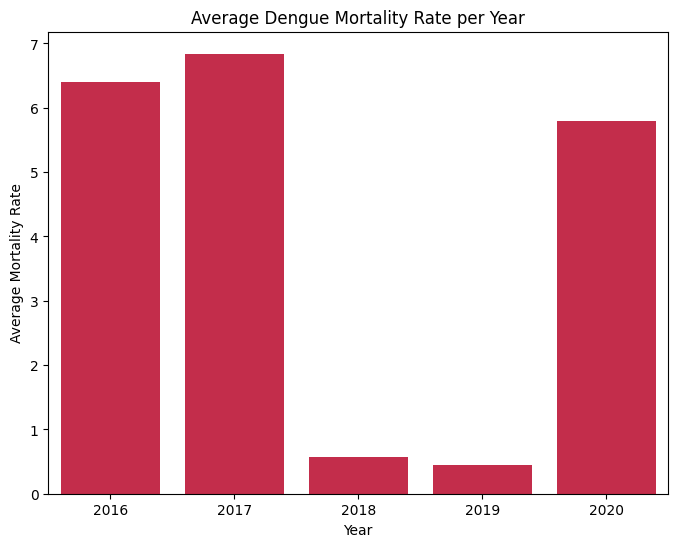

In [23]:
yearly_mortality = dengue.groupby("Year")["Mortality_Rate"].mean()

plt.figure(figsize=(8,6))
sns.barplot(x=yearly_mortality.index, y=yearly_mortality.values, color="crimson")
plt.title("Average Dengue Mortality Rate per Year")
plt.xlabel("Year")
plt.ylabel("Average Mortality Rate")
plt.show()

<h4><b>INSIGHT:</b>The bar graph shows the average dengue mortality rate per year across all regions. In 2017, the average dengue mortality rate was the highest compared to other years. The mortality rate was also relatively high in 2016 and 2020. However, the years 2018 and 2019 saw a significant drop in the average mortality rate. This information is useful for understanding the years in which dengue was most deadly. Public health officials can use this data to plan for future outbreaks and allocate resources effectively.


</h4>

<h2>What is the relationship between dengue cases and dengue deaths?</h2>

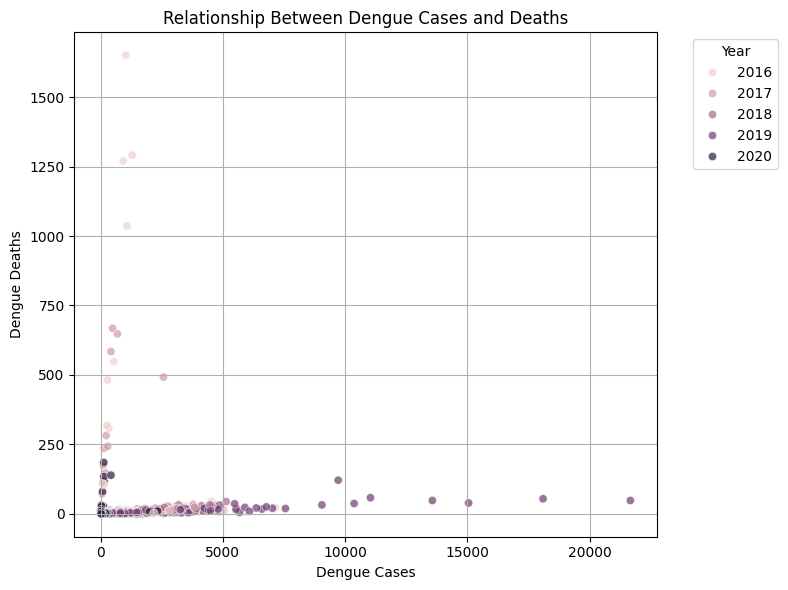

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=dengue, x="Dengue_Cases", y="Dengue_Deaths", hue="Year", alpha=0.7)
plt.title("Relationship Between Dengue Cases and Deaths")
plt.xlabel("Dengue Cases")
plt.ylabel("Dengue Deaths")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><b>INSIGHT:</b>The scatter plot shows the relationship between the number of dengue cases and dengue-related deaths. In general, the graph indicates that as the number of dengue cases increases, the number of deaths also rises. However, the pattern is not completely consistent, as some points do not follow the expected trend. the plot highlights that while more cases often lead to more deaths, the connection between them is not always direct.</h4>